# Bloc 03 - The North Face ecommerce

## 03 - Topic modeling

## Import librairies

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wordcloud
from IPython.display import Image, display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
data = pd.read_csv("data/data_cleaned.csv")

vectorizer = TfidfVectorizer(max_df=0.99, min_df=0.01)
X = vectorizer.fit_transform(data["description_cleaned"])

In [3]:
nb_topics = 10
svd_model = TruncatedSVD(n_components=nb_topics, n_iter=100, random_state=42)
lsa = svd_model.fit_transform(X)

topic_encoded_df = pd.DataFrame(lsa, columns = [f"topic_{i}" for i in range(nb_topics)])
topic_encoded_df["documents"] = data['description_cleaned']
topic_encoded_df

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,documents
0,0.224738,-0.031307,0.032716,0.116413,-0.047864,-0.039020,0.017818,-0.052463,-0.003953,-0.061494,active classic boxer s reason boxer cult favor...
1,0.207683,-0.059813,0.067207,0.104864,-0.061475,0.040465,-0.015275,-0.065695,0.059127,-0.003180,active sport boxer brief skin glory require mo...
2,0.203117,-0.064662,0.074014,0.058888,-0.050723,0.114861,0.001626,-0.022058,-0.007058,-0.039081,active sport brief superbreathable nofly brief...
3,0.276308,-0.173635,-0.056665,-0.082004,0.024589,-0.100973,-0.009881,0.069499,0.287387,-0.036737,alpine guide pant skin climb ice switch rock t...
4,0.279324,-0.167217,0.065459,-0.243248,-0.038671,-0.056438,0.018175,0.121989,0.119089,0.091815,alpine wind jkt high ridge steep ice alpine ja...
...,...,...,...,...,...,...,...,...,...,...,...
495,0.318461,-0.091742,0.245525,0.110104,-0.340832,-0.091630,-0.006442,-0.179072,0.128208,-0.191846,cap cut loose madden crowd search undone capil...
496,0.321834,-0.069076,0.392678,0.064604,-0.307434,-0.045259,0.005869,-0.154372,0.017233,-0.129409,cap crew crew edge fickle weather clearing con...
497,0.293934,-0.165100,0.080689,-0.170850,-0.022589,-0.030282,-0.002517,0.123937,0.026808,-0.016600,alltime shell need use morning time umbrella a...
498,0.270099,-0.042282,-0.181033,0.223970,0.018381,-0.172634,-0.034212,-0.067863,-0.053808,-0.014696,allwear cargo short allwear cargo short bask g...


In [4]:
def get_topic_terms(V, terms, n_top_terms):
    '''
    Retrieve n_top_terms terms associated with our truncated SVD topics.

    V (numpy.ndarray): V* matrix of our SVD of shape (topics, terms)
    terms (list): List of terms used in our SVD
    n_top_terms (int): Amount of terms to return per topic

    Output (numpy.ndarray(numpy.ndarray)): Array of arrays, top terms by topics
    '''

    top_topic_terms = []
    # For each topic vector in our right singular vectors of shape (topics, terms)
    for topic_vec in V:
        # Get sorted term indices, in ascending order, limited to top terms
        indices = np.argsort(topic_vec)[::-1]
        word_freq = {terms[i]: abs(topic_vec[i]) for i in indices[:n_top_terms]}

        top_topic_terms.append(word_freq)
        
    return top_topic_terms

topic_terms = get_topic_terms(svd_model.components_, vectorizer.get_feature_names_out(), 10)

for topic, terms in enumerate(topic_terms):
    print(f"Key terms for topic {topic+1} are {list(terms.keys())}")

Key terms for topic 1 are ['pocket', 'recycle', 'tshirt', 'recyclable', 'program', 'thread', 'common', 'organic', 'short', 'cotton']
Key terms for topic 2 are ['tshirt', 'phthalatefree', 'ink', 'pvc', 'ringspun', 'tape', 'organic', 'cotton', 'print', 'tee']
Key terms for topic 3 are ['merino', 'dry', 'odor', 'layer', 'temperature', 'beneath', 'control', 'warm', 'cap', 'wool']
Key terms for topic 4 are ['merino', 'short', 'inseam', 'pant', 'size', 'organic', 'cotton', 'long', 'button', 'regular']
Key terms for topic 5 are ['merino', 'wool', 'temperature', 'machinewash', 'slowwash', 'lie', 'regulate', 'away', 'resist', 'body']
Key terms for topic 6 are ['spandex', 'blend', 'coverage', 'btm', 'line', 'nylon', 'solid', 'hip', 'scoop', 'print']
Key terms for topic 7 are ['photo', 'outside', 'poster', 'photograph', 'human', 'brighten', 'catalog', 'specialty', 'clothier', 'wall']
Key terms for topic 8 are ['shirt', 'fleece', 'organic', 'cuff', 'hem', 'cotton', 'jacket', 'handwarmer', 'jkt', '

Topic 0 {'pocket': np.float64(0.19509148972503662), 'recycle': np.float64(0.18749136046573936), 'tshirt': np.float64(0.166593044118626), 'recyclable': np.float64(0.16457253024127572), 'program': np.float64(0.1623468717345464), 'thread': np.float64(0.16234145636117592), 'common': np.float64(0.16228702903989975), 'organic': np.float64(0.15443041531638504), 'short': np.float64(0.15235103320060356), 'cotton': np.float64(0.14465305274133003)}


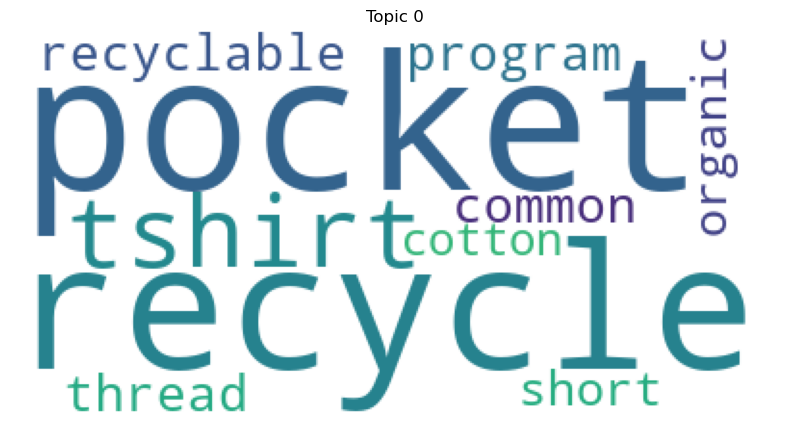

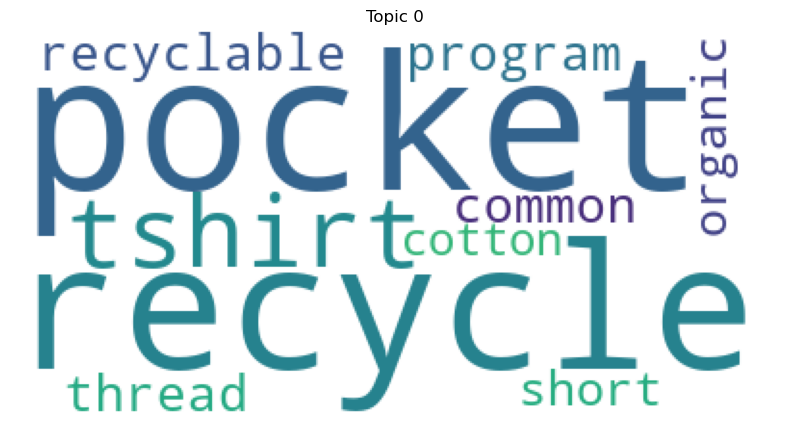

Topic 1 {'tshirt': np.float64(0.38866801836051823), 'phthalatefree': np.float64(0.2202481947356567), 'ink': np.float64(0.2202481947356567), 'pvc': np.float64(0.2202481947356567), 'ringspun': np.float64(0.22021670907679075), 'tape': np.float64(0.19617547628138035), 'organic': np.float64(0.18261047001398856), 'cotton': np.float64(0.16715101466182813), 'print': np.float64(0.15982043014249592), 'tee': np.float64(0.14876583740264743)}


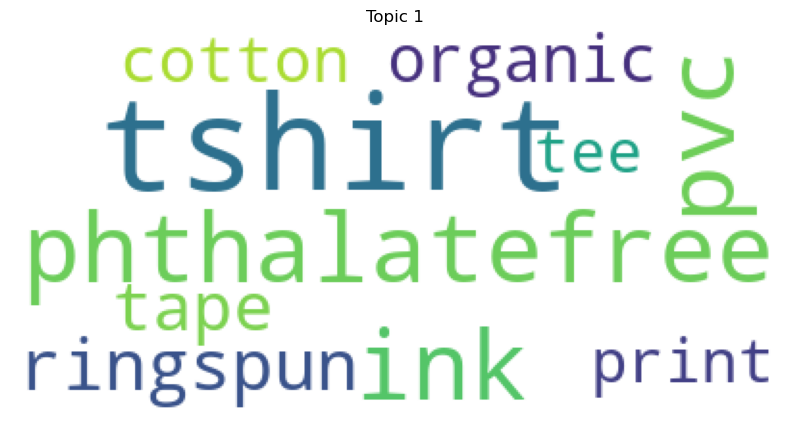

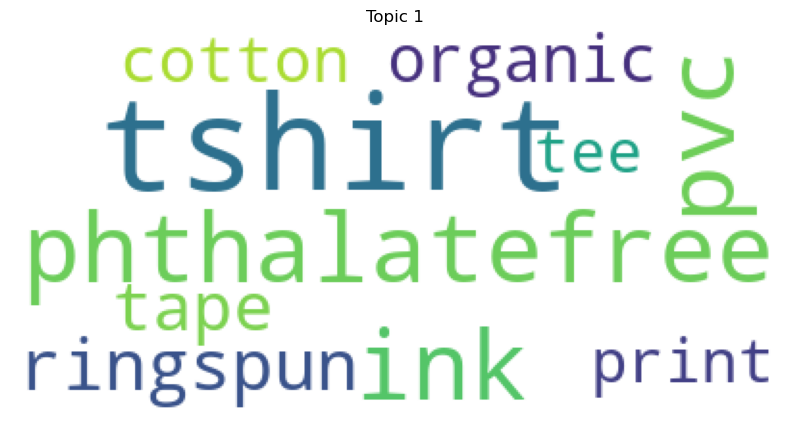

Topic 2 {'merino': np.float64(0.37272019542436335), 'dry': np.float64(0.16587936951012502), 'odor': np.float64(0.1585776441387195), 'layer': np.float64(0.13358563059020523), 'temperature': np.float64(0.11967482532776758), 'beneath': np.float64(0.11693110788316137), 'control': np.float64(0.11548955317793085), 'warm': np.float64(0.11338586902122862), 'cap': np.float64(0.11310659569453524), 'wool': np.float64(0.1073285056438632)}


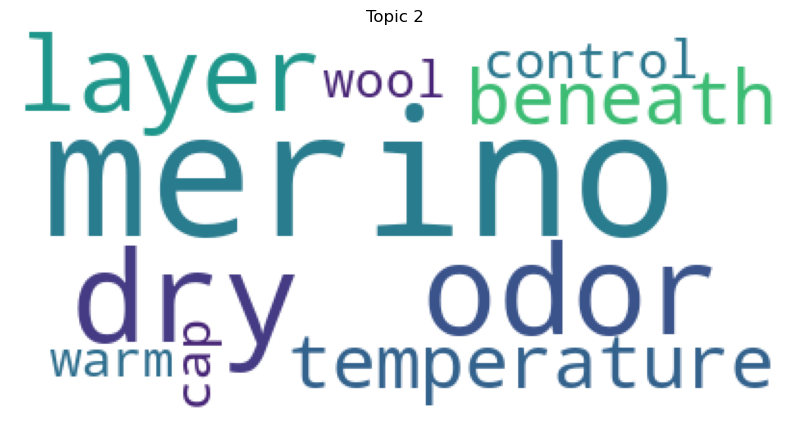

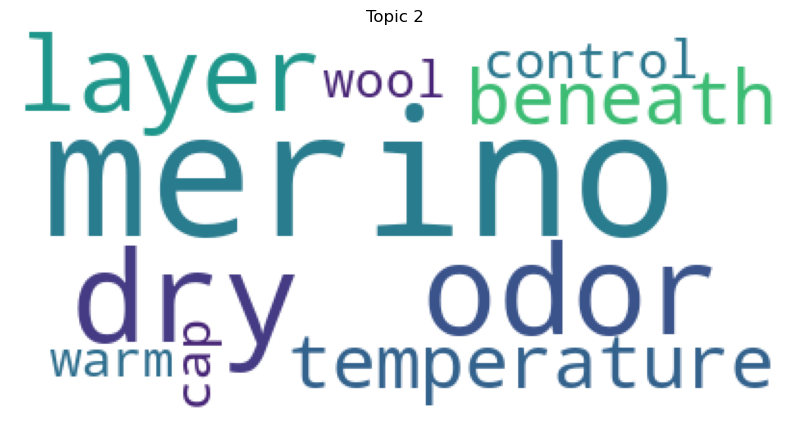

Topic 3 {'merino': np.float64(0.2217140256499965), 'short': np.float64(0.21942904305557137), 'inseam': np.float64(0.15135523256140737), 'pant': np.float64(0.12444592418921178), 'size': np.float64(0.11702376353289082), 'organic': np.float64(0.11245350736880536), 'cotton': np.float64(0.09632240543054986), 'long': np.float64(0.09576574423606934), 'button': np.float64(0.09015108612984023), 'regular': np.float64(0.09010896673955374)}


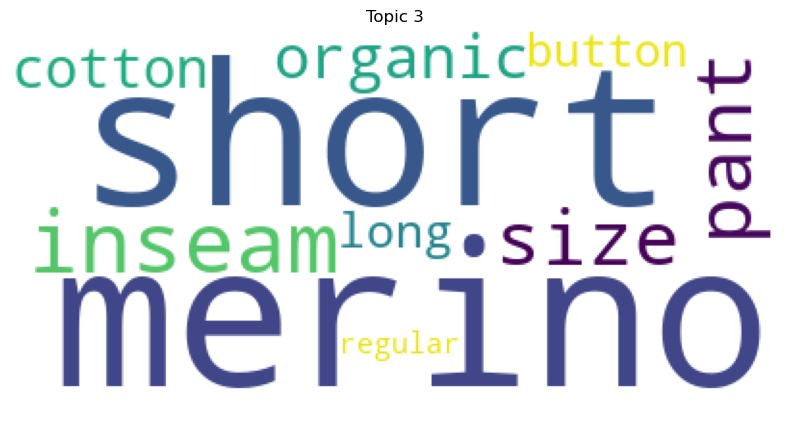

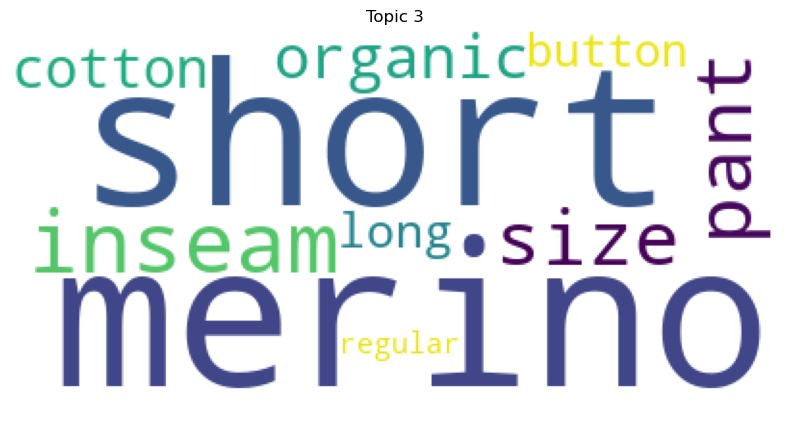

Topic 4 {'merino': np.float64(0.452539601321183), 'wool': np.float64(0.12871027497722543), 'temperature': np.float64(0.11902947597737377), 'machinewash': np.float64(0.0992534256516701), 'slowwash': np.float64(0.0992534256516701), 'lie': np.float64(0.0958577923593041), 'regulate': np.float64(0.09583736994717866), 'away': np.float64(0.09180064763209485), 'resist': np.float64(0.09175953233597282), 'body': np.float64(0.09096773535195272)}


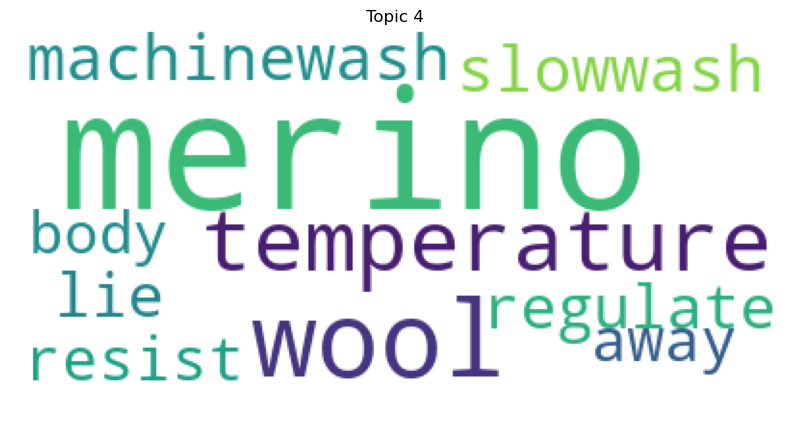

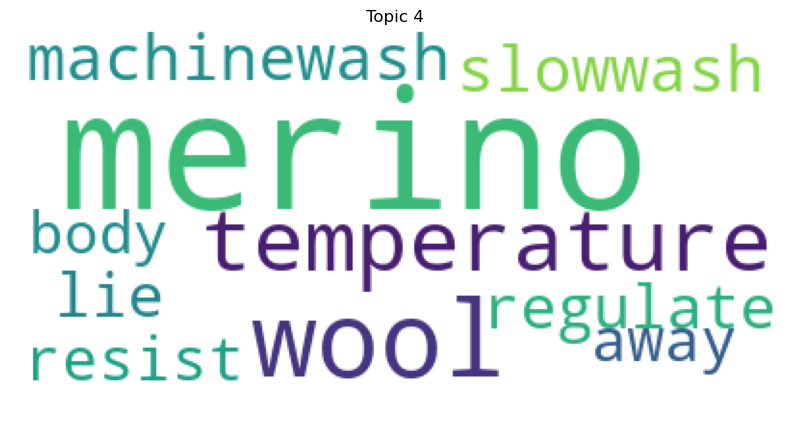

Topic 5 {'spandex': np.float64(0.3094227259987572), 'blend': np.float64(0.30413490744185706), 'coverage': np.float64(0.29517145282606877), 'btm': np.float64(0.263390252947173), 'line': np.float64(0.23948460385219872), 'nylon': np.float64(0.21524875079414946), 'solid': np.float64(0.1756770899558148), 'hip': np.float64(0.15577087766515924), 'scoop': np.float64(0.14792388945473395), 'print': np.float64(0.12892753011098776)}


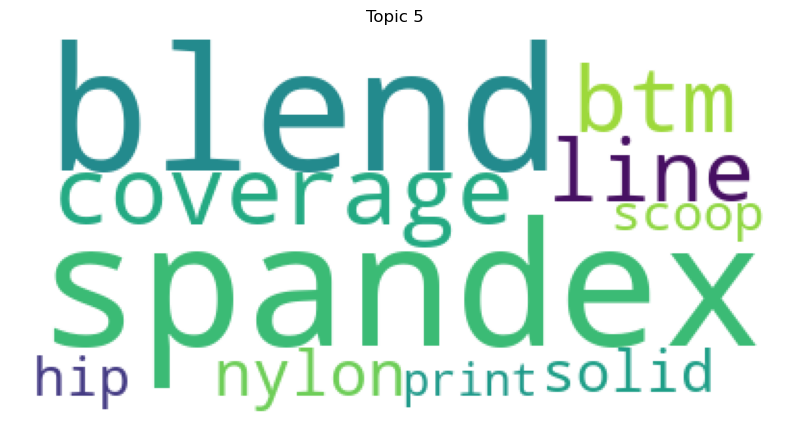

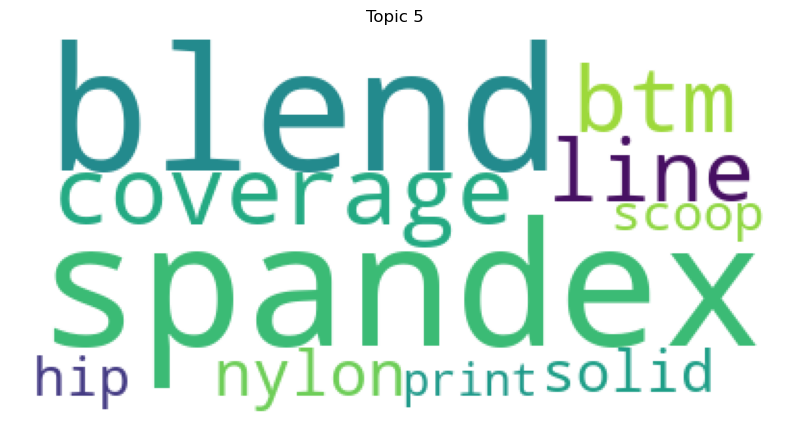

Topic 6 {'photo': np.float64(0.28783279283306024), 'outside': np.float64(0.28318401490002004), 'poster': np.float64(0.27562807649955834), 'photograph': np.float64(0.14682142242663135), 'human': np.float64(0.14682142242663135), 'brighten': np.float64(0.14682142242663135), 'catalog': np.float64(0.14682142242663135), 'specialty': np.float64(0.14682142242663135), 'clothier': np.float64(0.14682142242663135), 'wall': np.float64(0.14682142242663135)}


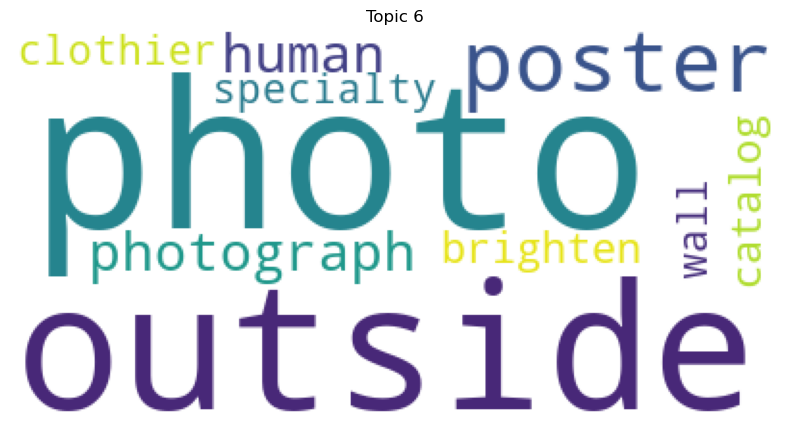

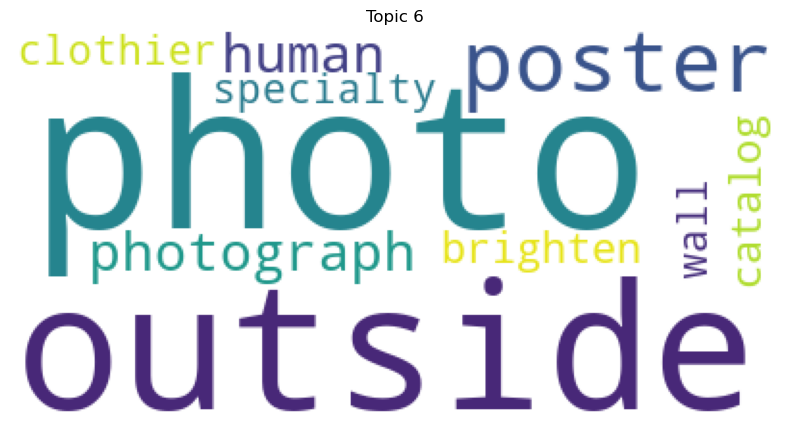

Topic 7 {'shirt': np.float64(0.1632225531314784), 'fleece': np.float64(0.1554027060467217), 'organic': np.float64(0.15532951278621532), 'cuff': np.float64(0.15133064545044905), 'hem': np.float64(0.14700271662707826), 'cotton': np.float64(0.13769856572121175), 'jacket': np.float64(0.13679609189754321), 'handwarmer': np.float64(0.13530642142107394), 'jkt': np.float64(0.12905778572058504), 'hood': np.float64(0.11345787901806217)}


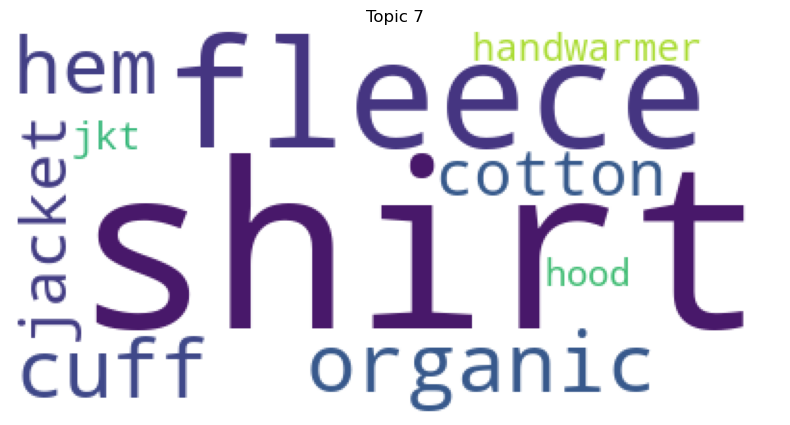

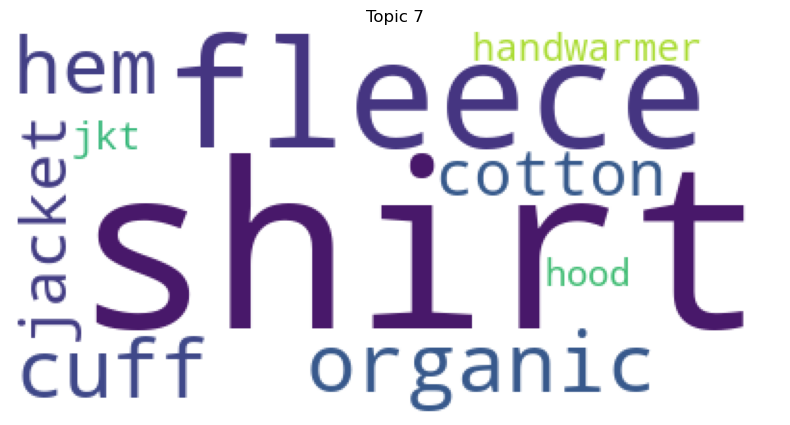

Topic 8 {'pant': np.float64(0.3181319809236706), 'guide': np.float64(0.11453200284337124), 'btm': np.float64(0.11075851183533303), 'tshirt': np.float64(0.10335718308514007), 'gussete': np.float64(0.09812895871092352), 'coverage': np.float64(0.09439647931757084), 'leg': np.float64(0.09237602645898459), 'loop': np.float64(0.0915085329573828), 'print': np.float64(0.0913022171773241), 'line': np.float64(0.08981807116339136)}


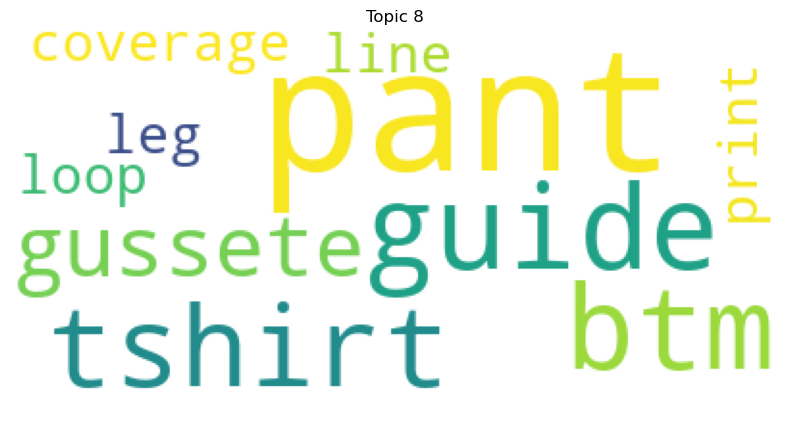

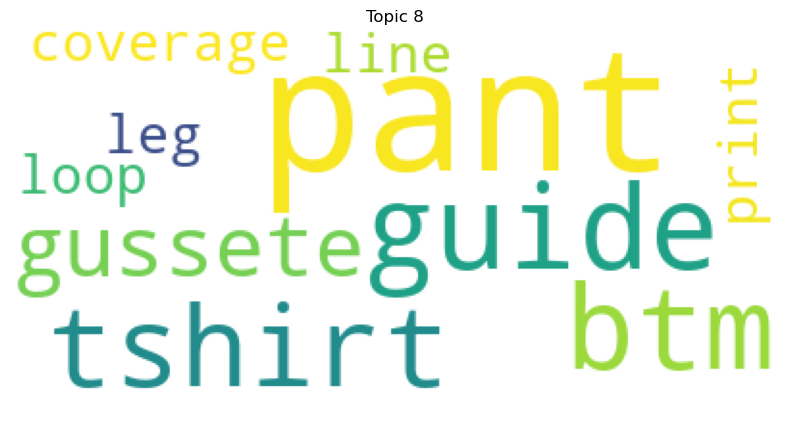

Topic 9 {'sun': np.float64(0.2548148920627544), 'shirt': np.float64(0.21638822281006612), 'upf': np.float64(0.16670434333553522), 'allrecycle': np.float64(0.15917956790243618), 'rashguard': np.float64(0.15330357997195282), 'reflective': np.float64(0.14536179576882532), 'logo': np.float64(0.13537190996132592), 'protection': np.float64(0.12012580603421491), 'vent': np.float64(0.11090360161123718), 'visible': np.float64(0.10913380706509407)}


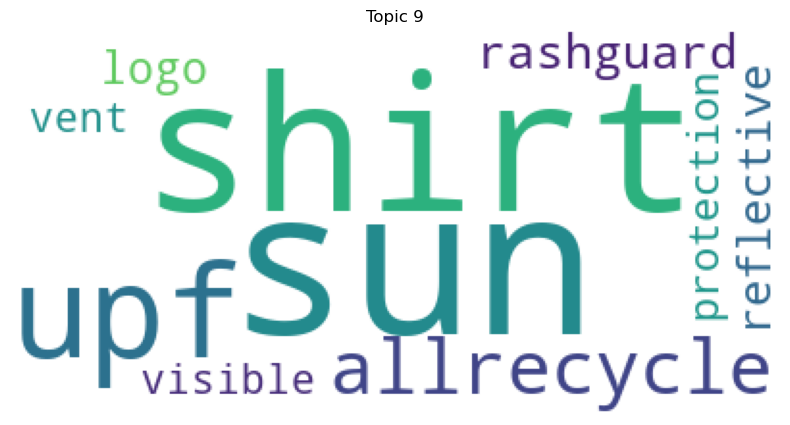

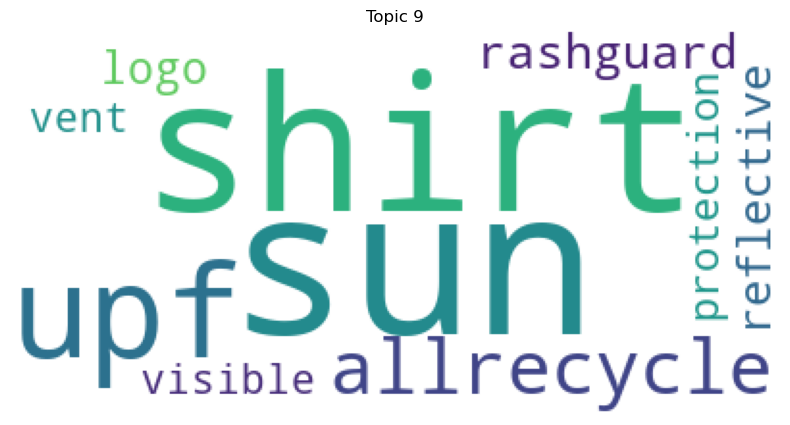

In [5]:
for i, topic in enumerate(topic_terms):
    wc = wordcloud.WordCloud(background_color="white").generate_from_frequencies(topic)

    print(f"Topic {i} {topic}")
    
    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {i}")

    filename = f"images/topic_{i}.png"
    plt.savefig(filename, bbox_inches="tight")

    plt.show()
    
    display(Image(filename))